# 020 — Analyze KSC weather and effective acoustic speed

Use KSC tower observations and the canonical SLC-40–BCHH geometry from Notebook 010 to estimate still-air sound speed, along-path wind, effective acoustic speed, and short-range travel time.


Useful and self-contained.
It produces:
* path-averaged acoustic-speed estimates;
* along-ray wind corrections;
* height and time profiles;
* concise paper values;
* supplementary plots and CSV outputs.
This is a good supporting notebook. It does not need to be embedded tightly in the event-catalogue chain.
I would keep the name and number.
Verdict: keep.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
from pyproj import Geod


project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

from modules.weather_analysis import (
    KNOT_TO_MPS,
    along_ray_wind_component,
    calculate_acoustic_summary,
    load_ksc_weather_excel,
    make_height_profile,
    make_time_profile,
    path_average_wind_profile,
    subset_time_window,
    summarize_wind,
)

from modules.physics import compute_speed_of_sound, compute_speed_of_sound_cramer

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 1. Configuration

In [2]:
WEATHER_FILE = config.METADATA_DIR / "nasa_weather_tower_data.xls"
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"

if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Run 010_prepare_analysis_inputs.ipynb first: {ANALYSIS_CONFIG_FILE}"
    )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
slc40 = analysis_config["slc40"]
array_reference = analysis_config["array_reference"]

ANALYSIS_START = pd.Timestamp("2016-09-01T13:05:00Z")
ANALYSIS_END = pd.Timestamp("2016-09-01T13:35:00Z")
MAXIMUM_PATH_HEIGHT_M = 65.0
HEIGHT_BIN_M = 10.0
# Comparison assumptions, not measurements from the tower spreadsheet.
CRAMER_PRESSURE_PA = 101325.0
CRAMER_CO2_PPM = 400.0

geod = Geod(ellps="WGS84")
ray_azimuth_deg, _, propagation_distance_m = geod.inv(
    slc40["longitude"], slc40["latitude"],
    array_reference["longitude"], array_reference["latitude"],
)
ray_azimuth_deg %= 360.0

print(f"Weather file: {WEATHER_FILE}")
print(f"Analysis interval: {ANALYSIS_START} to {ANALYSIS_END}")
print(f"SLC-40 → BCHH azimuth: {ray_azimuth_deg:.3f}°")
print(f"SLC-40 → BCHH distance: {propagation_distance_m:.1f} m")


Weather file: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/metadata/nasa_weather_tower_data.xls
Analysis interval: 2016-09-01 13:05:00+00:00 to 2016-09-01 13:35:00+00:00
SLC-40 → BCHH azimuth: 19.436°
SLC-40 → BCHH distance: 1419.9 m


## 2. Load and validate the spreadsheet

In [3]:
weather_all = load_ksc_weather_excel(WEATHER_FILE)
weather = subset_time_window(
    weather_all,
    ANALYSIS_START,
    ANALYSIS_END,
)

print(f"All rows: {len(weather_all)}")
print(f"Rows in analysis interval: {len(weather)}")
print(
    "Towers/measurement locations:",
    weather["Tower Measurement Location"].nunique(),
)
print(
    "Height range:",
    f"{weather['height_m'].min():.1f}–"
    f"{weather['height_m'].max():.1f} m",
)
print("Observation times:", weather["datetime_utc"].nunique())

display(
    weather[
        [
            "datetime_utc",
            "Tower Measurement Location",
            "height_ft",
            "height_m",
            "wind_direction_from_deg",
            "wind_speed_knots",
            "temperature_f",
            "relative_humidity_percent",
        ]
    ].head()
)

All rows: 180
Rows in analysis interval: 105
Towers/measurement locations: 3
Height range: 16.5–139.9 m
Observation times: 7


,datetime_utc,Tower Measurement Location,height_ft,height_m,wind_direction_from_deg,wind_speed_knots,temperature_f,relative_humidity_percent
0,2016-09-01 13:05:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
1,2016-09-01 13:10:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
2,2016-09-01 13:15:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
3,2016-09-01 13:20:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
4,2016-09-01 13:25:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN


## 3. Overall atmospheric summaries

In [4]:
wind_summary = summarize_wind(weather)

overall_summary = pd.DataFrame(
    [
        {
            "analysis_start_utc": ANALYSIS_START,
            "analysis_end_utc": ANALYSIS_END,
            "n_rows": len(weather),
            "n_locations": weather[
                "Tower Measurement Location"
            ].nunique(),
            "minimum_height_m": weather["height_m"].min(),
            "maximum_height_m": weather["height_m"].max(),
            "mean_temperature_f": weather["temperature_f"].mean(),
            "std_temperature_f": weather["temperature_f"].std(),
            "n_temperature": weather["temperature_f"].count(),
            "mean_relative_humidity_percent": weather[
                "relative_humidity_percent"
            ].mean(),
            "std_relative_humidity_percent": weather[
                "relative_humidity_percent"
            ].std(),
            "n_humidity": weather[
                "relative_humidity_percent"
            ].count(),
            "scalar_mean_wind_speed_knots": (
                wind_summary.scalar_mean_speed_knots
            ),
            "vector_mean_wind_speed_knots": (
                wind_summary.vector_mean_speed_knots
            ),
            "vector_mean_wind_direction_from_deg": (
                wind_summary.vector_mean_direction_from_deg
            ),
        }
    ]
)

display(overall_summary.T)
overall_summary.to_csv(
    config.NB020_DIR / "weather_overall_summary.csv",
    index=False,
)

,0
analysis_start_utc,2016-09-01 13:05:00+00:00
analysis_end_utc,2016-09-01 13:35:00+00:00
n_rows,105
n_locations,3
minimum_height_m,16.4592
maximum_height_m,139.9032
mean_temperature_f,79.444048
std_temperature_f,0.49023
n_temperature,84
mean_relative_humidity_percent,83.869048


## 4. Height and time profiles

In [5]:
height_profile = make_height_profile(
    weather,
    height_bin_m=HEIGHT_BIN_M,
)
time_profile = make_time_profile(weather)

height_profile["wind_along_slc40_bchh_mps"] = (
    along_ray_wind_component(
        height_profile["mean_u_east_mps"],
        height_profile["mean_v_north_mps"],
        ray_azimuth_deg,
    )
)

display(height_profile)
display(time_profile)

height_profile.to_csv(
    config.NB020_DIR / "weather_height_profile.csv",
    index=False,
)
time_profile.to_csv(
    config.NB020_DIR / "weather_time_profile.csv",
    index=False,
)

,height_bin_lower_m,height_bin_upper_m,height_bin_mid_m,n_wind,mean_height_m,mean_u_east_mps,mean_v_north_mps,scalar_mean_wind_speed_mps,scalar_std_wind_speed_mps,mean_temperature_c,std_temperature_c,n_temperature,mean_relative_humidity_percent,std_relative_humidity_percent,n_humidity,vector_mean_wind_speed_mps,vector_mean_wind_speed_knots,vector_mean_wind_direction_from_deg,wind_along_slc40_bchh_mps
0,10.0,20.0,15.0,0,16.4592,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN
1,40.0,50.0,45.0,21,40.5384,-2.499971,3.572922,4.385023,1.191236,26.719577,0.101647,21,86.428571,4.577897,21,4.360691,8.476513,145.019539,2.537457
2,70.0,80.0,75.0,35,75.2856,-3.462601,4.792332,6.041042,1.716873,26.462963,0.073142,21,83.285714,1.230563,21,5.912364,11.492726,144.150782,3.367066
3,110.0,120.0,115.0,21,116.7384,-3.228676,4.560392,5.634387,2.554028,26.171958,0.085895,21,81.666667,4.553387,21,5.587622,10.861478,144.702190,3.226181
4,130.0,140.0,135.0,21,139.5984,-3.216148,4.133067,5.340419,3.562227,26.076720,0.128472,21,84.095238,1.480026,21,5.236970,10.179864,142.111718,2.827376


,datetime_utc,n_wind,mean_u_east_mps,mean_v_north_mps,scalar_mean_wind_speed_mps,scalar_std_wind_speed_mps,mean_temperature_c,std_temperature_c,n_temperature,mean_relative_humidity_percent,std_relative_humidity_percent,n_humidity,vector_mean_wind_speed_mps,vector_mean_wind_speed_knots,vector_mean_wind_direction_from_deg
0,2016-09-01 13:05:00+00:00,14,-3.167292,4.187671,5.328170,2.384159,26.254630,0.246705,12,83.333333,3.749747,12,5.250555,10.206271,142.898422
1,2016-09-01 13:10:00+00:00,14,-3.314409,4.294588,5.511900,2.458330,26.291667,0.262857,12,83.666667,3.797926,12,5.424832,10.545038,142.340329
2,2016-09-01 13:15:00+00:00,14,-3.185355,4.260481,5.401662,2.485683,26.319444,0.287336,12,83.833333,4.018895,12,5.319604,10.340492,143.216322
3,2016-09-01 13:20:00+00:00,14,-3.201110,4.202360,5.364916,2.493568,26.351852,0.268359,12,84.000000,3.813850,12,5.282702,10.268759,142.701983
4,2016-09-01 13:25:00+00:00,14,-3.271803,4.372129,5.548646,2.456259,26.388889,0.271133,12,83.833333,3.996210,12,5.460788,10.614932,143.191325
5,2016-09-01 13:30:00+00:00,14,-3.164800,4.455090,5.548646,2.505494,26.435185,0.276089,12,84.083333,3.848455,12,5.464776,10.622685,144.610832
6,2016-09-01 13:35:00+00:00,14,-2.768925,4.608082,5.438408,2.410544,26.462963,0.296191,12,84.333333,3.797926,12,5.375999,10.450115,148.998994


## 5. Path-averaged wind and acoustic-speed calculation
The temperature and humidity means pool available tower/height/time observations;
they are not restricted to 0–65 m. Wind is vector-averaged in height bins,
linearly interpolated, and vertically averaged over 0–65 m. Below the lowest
valid wind height the code holds the wind constant. This is a representative
profile assumption, not a measured near-ground wind or a ray-tracing result.
The travel-time distance is SLC-40 to the BCHH seismometer (about 1419.9 m),
not the DD2 distance. The shaded temporal bands are spatial standard deviations,
not uncertainty intervals on the propagation model.

The retained approximation is c = 331.3 + 0.606 T_C + 1.26 RH/100 (m/s).
It is now compared below with the Cramer zero-frequency model at the observed
mean conditions. This comparison does not establish sub-m/s field accuracy;
no change to the adopted speed or downstream timing is made in this revision. A reference for a more complete comparison is the NPL-hosted LaVA
report, which describes the Cramer formulation and its applicability:
https://empir.npl.co.uk/lava/wp-content/uploads/sites/51/2022/08/17IND03-Final_Publishable_Report_For_Website.pdf


Reference-model citation: Cramer, O. (1993), The variation of the specific heat
ratio and the speed of sound in air with temperature, pressure, humidity, and
CO2 concentration, J. Acoust. Soc. Am. 93(5), 2510–2516,
https://doi.org/10.1121/1.405827 . Cramer's interpolating polynomial uses
Celsius temperature, pressure, water-vapour mole fraction and CO2 mole fraction.
It is not the simple linear approximation executed above, and should not be
cited as the derivation of that approximation. The original publisher PDF
could not be retrieved during this review; the polynomial structure is
corroborated by the NPL-hosted LaVA report linked above. Coefficients are now corroborated against pyfar 0.8.0 and a numerical comparison
is exported below; direct verification against the original PDF remains outstanding.

Do not treat the often-quoted approximately 300-ppm model uncertainty as a
confidence interval for the field propagation estimate. Wong (1995),
J. Acoust. Soc. Am. 97, 3177–3179, https://doi.org/10.1121/1.411818 ,
explicitly challenges Cramer's underlying uncertainty estimates. Input and
path-representativeness uncertainties must be considered separately.

The comparison below uses explicitly assumed 101325 Pa pressure and 400 ppm CO2.
It evaluates both models at the same pooled temperature/RH means. It does not
validate the spatial representativeness of the tower weather or change the
adopted downstream speed.


In [6]:
path_wind = path_average_wind_profile(
    height_profile,
    maximum_height_m=MAXIMUM_PATH_HEIGHT_M,
    ray_azimuth_deg=ray_azimuth_deg,
)

acoustic_summary = calculate_acoustic_summary(
    weather,
    height_profile=height_profile,
    maximum_path_height_m=MAXIMUM_PATH_HEIGHT_M,
    ray_azimuth_deg=ray_azimuth_deg,
    propagation_distance_m=propagation_distance_m,
    compute_speed_of_sound=compute_speed_of_sound,
)

acoustic_summary_df = pd.DataFrame([acoustic_summary])
display(acoustic_summary_df.T)

acoustic_summary_df.to_csv(
    config.NB020_DIR / "weather_acoustic_summary.csv",
    index=False,
)
# Portable observation subset and explicit provenance for this calculation.
weather.to_csv(config.NB020_DIR / "weather_observations_used.csv", index=False)
valid_wind_heights = height_profile.dropna(
    subset=["mean_height_m", "mean_u_east_mps", "mean_v_north_mps"]
)["mean_height_m"]
weather_provenance = {
    "producer_notebook": "020_analyze_ksc_weather.ipynb",
    "input_file": str(WEATHER_FILE),
    "analysis_start_utc": ANALYSIS_START.isoformat(),
    "analysis_end_utc": ANALYSIS_END.isoformat(),
    "interval_endpoints_inclusive": True,
    "observation_rows": len(weather),
    "temperature_humidity_weighting": "available observations across all included heights, towers and times",
    "wind_weighting": "height-binned vector means; interpolated vertical average over 0–65 m",
    "lowest_valid_wind_profile_height_m": float(valid_wind_heights.min()),
    "below_observed_wind_profile": "constant nearest-value extension",
    "height_bin_m": HEIGHT_BIN_M,
    "maximum_path_height_m": MAXIMUM_PATH_HEIGHT_M,
    "sound_speed_formula": "331.3 + 0.606*T_C + 1.26*RH_percent/100",
    "sound_speed_reference_validation": "outstanding",
    "propagation_receiver": "BCHH seismometer, not DD2",
    "propagation_distance_m": float(propagation_distance_m),
    "uncertainty_status": "observation scatter is not a propagated model confidence interval",
}
(config.NB020_DIR / "weather_processing.json").write_text(
    json.dumps(weather_provenance, indent=2) + "\n", encoding="utf-8"
)

# Compare models at the same mean temperature/RH, wind and geometry.
cramer_summary = calculate_acoustic_summary(
    weather, height_profile=height_profile,
    maximum_path_height_m=MAXIMUM_PATH_HEIGHT_M,
    ray_azimuth_deg=ray_azimuth_deg,
    propagation_distance_m=propagation_distance_m,
    compute_speed_of_sound=compute_speed_of_sound_cramer,
    sound_speed_kwargs={"atmospheric_pressure_pa": CRAMER_PRESSURE_PA,
                        "co2_ppm": CRAMER_CO2_PPM},
)
comparison = pd.DataFrame([
    {"model": "legacy approximation", **acoustic_summary},
    {"model": "Cramer 1993 comparison", **cramer_summary},
])
comparison["speed_difference_from_legacy_mps"] = (
    comparison["effective_sound_speed_mps"] - acoustic_summary["effective_sound_speed_mps"]
)
comparison["travel_time_difference_from_legacy_s"] = (
    comparison["wind_corrected_travel_time_s"] - acoustic_summary["wind_corrected_travel_time_s"]
)
comparison["pressure_assumption_pa"] = [np.nan, CRAMER_PRESSURE_PA]
comparison["co2_assumption_ppm"] = [np.nan, CRAMER_CO2_PPM]
comparison.to_csv(config.NB020_DIR / "weather_sound_speed_model_comparison.csv", index=False)
display(comparison)
weather_provenance["cramer_comparison"] = {
    "citation_doi": "10.1121/1.405827",
    "coefficient_verification": "corroborated against pyfar 0.8.0; original PDF not checked",
    "pressure_pa": CRAMER_PRESSURE_PA, "co2_ppm": CRAMER_CO2_PPM,
    "input_status": "assumed, not measured",
    "adopted_downstream_model": "legacy approximation",
}
(config.NB020_DIR / "weather_processing.json").write_text(
    json.dumps(weather_provenance, indent=2) + "\n", encoding="utf-8"
)


,0
n_temperature,84
n_humidity,84
mean_temperature_f,79.444048
mean_temperature_c,26.357804
mean_relative_humidity_percent,83.869048
still_air_sound_speed_mps,348.329579
sound_speed_model,compute_speed_of_sound
sound_speed_parameters,{}
ray_azimuth_deg,19.435717
propagation_distance_m,1419.886511


,model,n_temperature,n_humidity,mean_temperature_f,mean_temperature_c,mean_relative_humidity_percent,still_air_sound_speed_mps,sound_speed_model,sound_speed_parameters,ray_azimuth_deg,...,path_vector_mean_wind_direction_from_deg,wind_along_ray_mps,effective_sound_speed_mps,still_air_travel_time_s,wind_corrected_travel_time_s,wind_travel_time_correction_s,speed_difference_from_legacy_mps,travel_time_difference_from_legacy_s,pressure_assumption_pa,co2_assumption_ppm
0,legacy approximation,84,84,79.444048,26.357804,83.869048,348.329579,compute_speed_of_sound,{},19.435717,...,144.870532,2.647354,350.976933,4.076273,4.045527,-0.030747,0.000000,0.000000,NaN,NaN
1,Cramer 1993 comparison,84,84,79.444048,26.357804,83.869048,348.617312,compute_speed_of_sound_cramer,"{'atmospheric_pressure_pa': 101325.0, 'co2_ppm...",19.435717,...,144.870532,2.647354,351.264666,4.072909,4.042213,-0.030696,0.287732,-0.003314,101325.0,400.0


1405

## 6. Wind rose: all average-wind observations

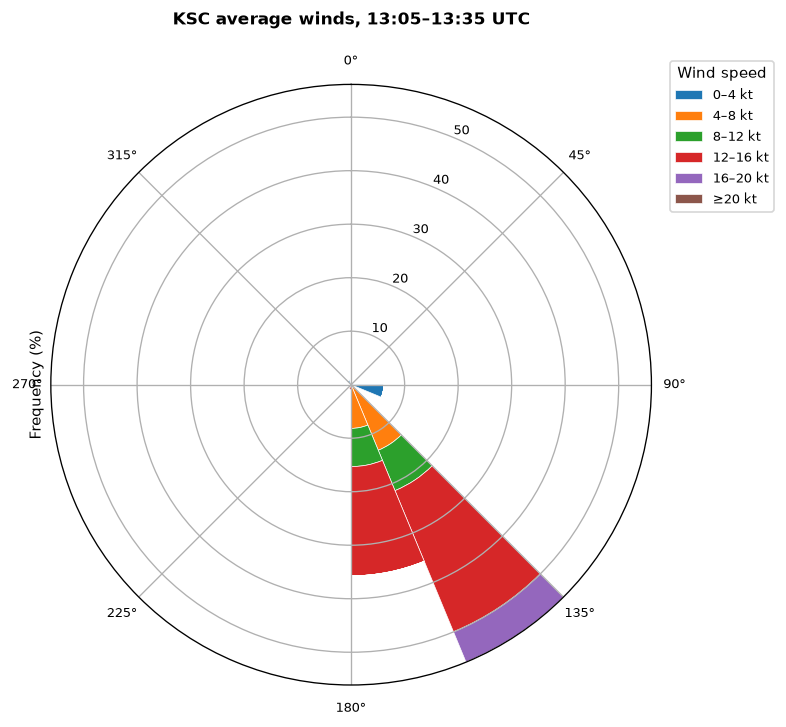

In [7]:
direction = weather["wind_direction_from_deg"].to_numpy(dtype=float)
speed = weather["wind_speed_knots"].to_numpy(dtype=float)

valid = np.isfinite(direction) & np.isfinite(speed)
direction = direction[valid]
speed = speed[valid]

direction_edges_deg = np.arange(0.0, 360.0 + 22.5, 22.5)
speed_edges_knots = np.array([0, 4, 8, 12, 16, 20, np.inf])

histogram = np.zeros(
    (len(direction_edges_deg) - 1, len(speed_edges_knots) - 1)
)

direction_wrapped = (
    direction + 0.5 * np.diff(direction_edges_deg)[0]
) % 360.0

for i in range(len(direction_edges_deg) - 1):
    direction_mask = (
        (direction_wrapped >= direction_edges_deg[i])
        & (direction_wrapped < direction_edges_deg[i + 1])
    )
    for j in range(len(speed_edges_knots) - 1):
        speed_mask = (
            (speed >= speed_edges_knots[j])
            & (speed < speed_edges_knots[j + 1])
        )
        histogram[i, j] = np.sum(direction_mask & speed_mask)

histogram = 100.0 * histogram / histogram.sum()

theta = np.deg2rad(
    direction_edges_deg[:-1]
    + 0.5 * np.diff(direction_edges_deg)
)
width = np.deg2rad(np.diff(direction_edges_deg))
bottom = np.zeros(len(theta))

fig = plt.figure(figsize=(7.0, 6.5))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

labels = []
for j in range(histogram.shape[1]):
    values = histogram[:, j]
    ax.bar(
        theta,
        values,
        width=width,
        bottom=bottom,
        align="center",
        edgecolor="white",
        linewidth=0.4,
        label=(
            f"{speed_edges_knots[j]:g}–"
            f"{speed_edges_knots[j + 1]:g} kt"
            if np.isfinite(speed_edges_knots[j + 1])
            else f"≥{speed_edges_knots[j]:g} kt"
        ),
    )
    bottom += values

ax.set_title(
    "KSC average winds, 13:05–13:35 UTC",
    pad=18,
    fontweight="bold",
)
ax.set_ylabel("Frequency (%)")
ax.legend(
    title="Wind speed",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.05),
)

fig.savefig(
    config.NB020_DIR / "weather_wind_rose.pdf",
    bbox_inches="tight",
)
plt.show()

## 7. Wind speed versus height

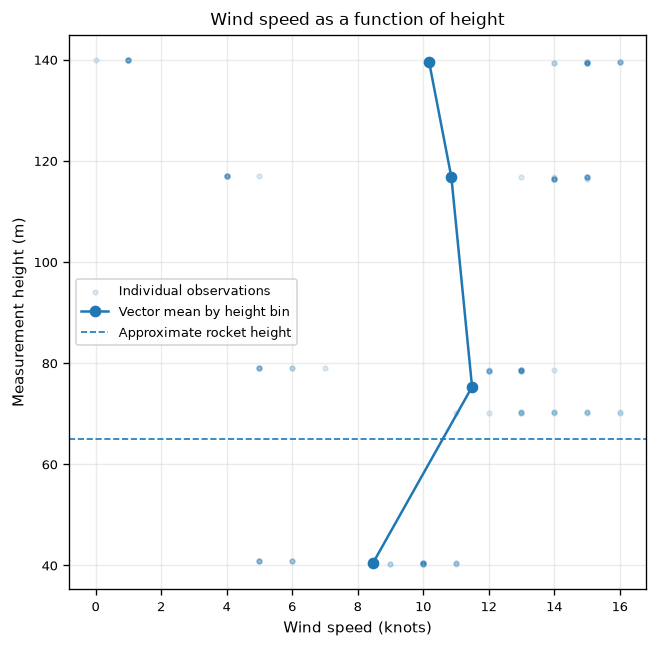

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.scatter(
    weather["wind_speed_knots"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    height_profile["vector_mean_wind_speed_knots"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Vector mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Wind speed (knots)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Wind speed as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    config.NB020_DIR / "weather_wind_speed_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 8. Wind direction versus height

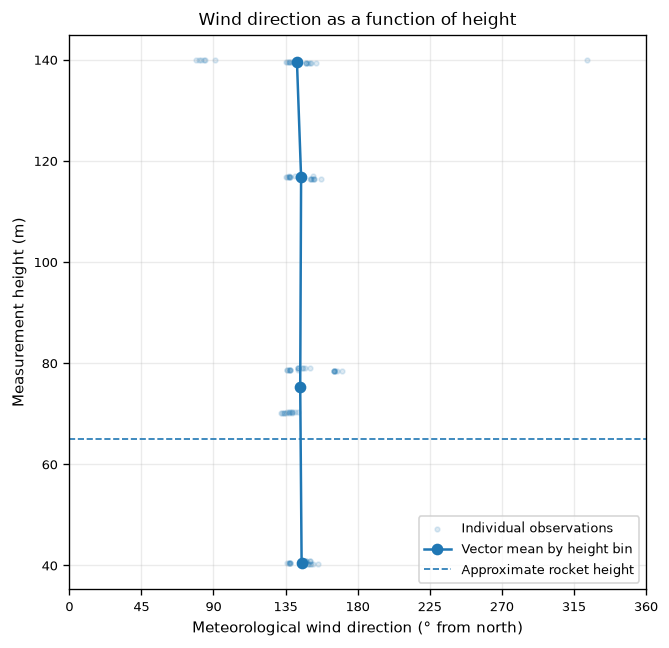

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.scatter(
    weather["wind_direction_from_deg"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    height_profile["vector_mean_wind_direction_from_deg"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Vector mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlim(0, 360)
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xlabel("Meteorological wind direction (° from north)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Wind direction as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    config.NB020_DIR / "weather_wind_direction_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 9. Along-ray wind correction versus height

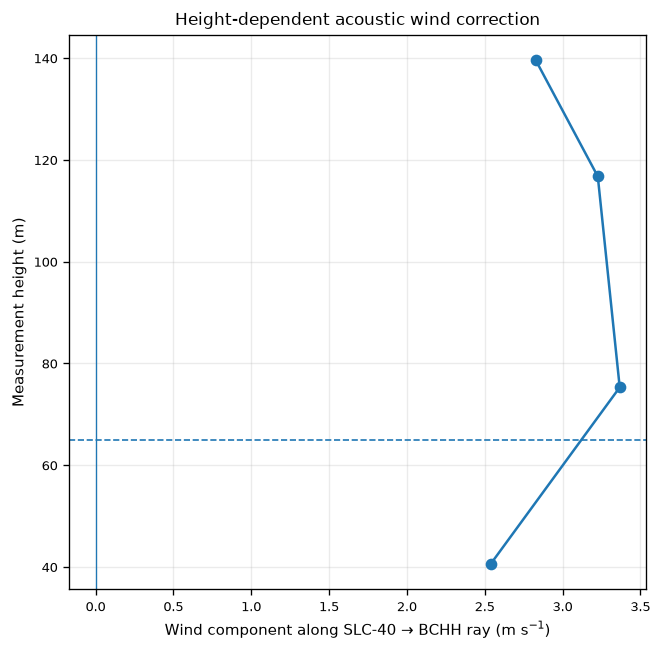

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.axvline(0.0, linewidth=0.8)
ax.plot(
    height_profile["wind_along_slc40_bchh_mps"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Wind component along SLC-40 → BCHH ray (m s$^{-1}$)"
)
ax.set_ylabel("Measurement height (m)")
ax.set_title("Height-dependent acoustic wind correction")
ax.grid(True, alpha=0.25)

fig.savefig(
    config.NB020_DIR / "weather_along_ray_wind_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 10. Temperature versus height

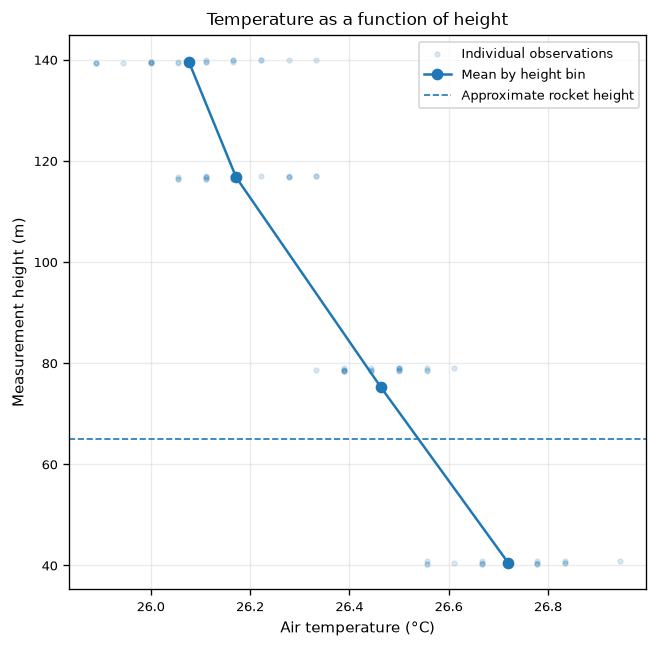

In [11]:
valid_profile = height_profile.dropna(
    subset=["mean_temperature_c"]
)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(
    weather["temperature_c"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    valid_profile["mean_temperature_c"],
    valid_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Temperature as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    config.NB020_DIR / "weather_temperature_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 11. Relative humidity versus height

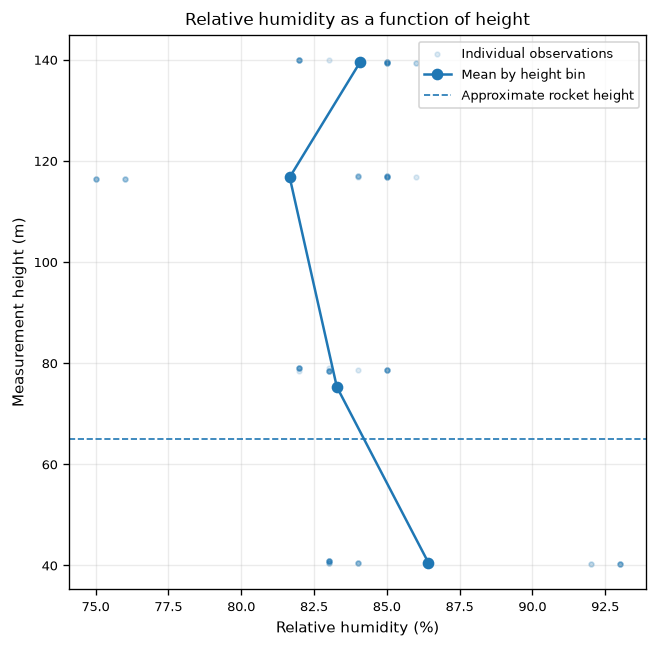

In [12]:
valid_profile = height_profile.dropna(
    subset=["mean_relative_humidity_percent"]
)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(
    weather["relative_humidity_percent"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    valid_profile["mean_relative_humidity_percent"],
    valid_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Relative humidity (%)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Relative humidity as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    config.NB020_DIR / "weather_humidity_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 12. Wind speed through time

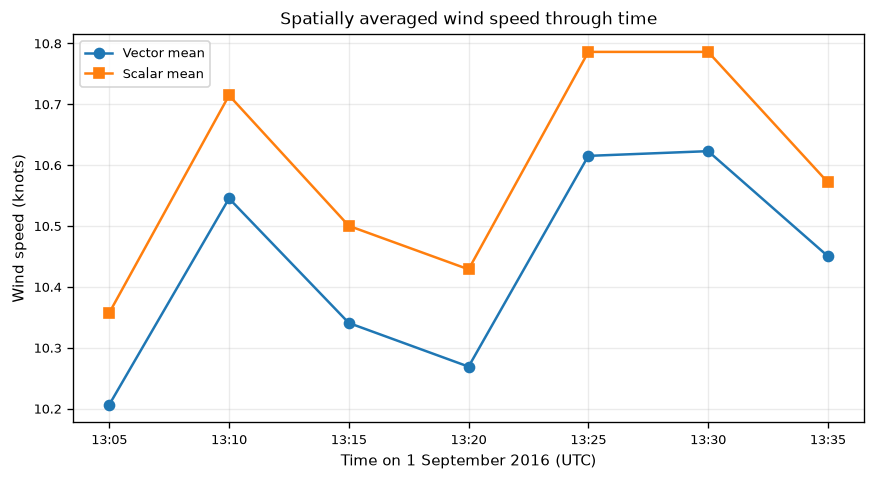

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["vector_mean_wind_speed_knots"],
    marker="o",
    label="Vector mean",
)
ax.plot(
    time_profile["datetime_utc"],
    time_profile["scalar_mean_wind_speed_mps"] / KNOT_TO_MPS,
    marker="s",
    label="Scalar mean",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Wind speed (knots)")
ax.set_title("Spatially averaged wind speed through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    config.NB020_DIR / "weather_wind_speed_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 13. Wind direction through time

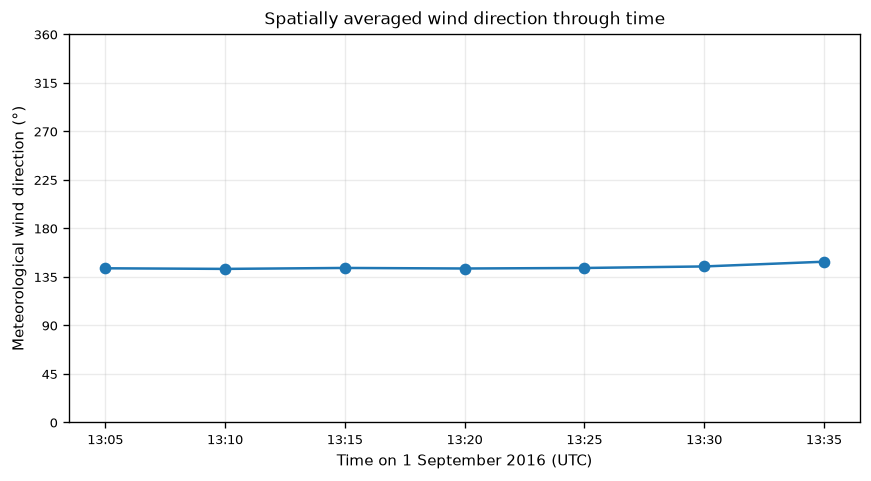

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["vector_mean_wind_direction_from_deg"],
    marker="o",
)

ax.set_ylim(0, 360)
ax.set_yticks(np.arange(0, 361, 45))
ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Meteorological wind direction (°)")
ax.set_title("Spatially averaged wind direction through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    config.NB020_DIR / "weather_wind_direction_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 14. Temperature through time

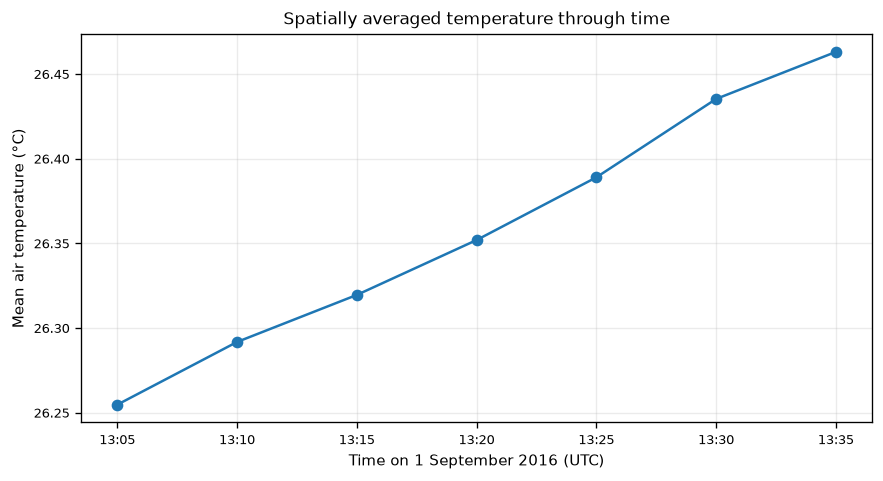

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["mean_temperature_c"],
    marker="o",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Mean air temperature (°C)")
ax.set_title("Spatially averaged temperature through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    config.NB020_DIR / "weather_temperature_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 15. Relative humidity through time

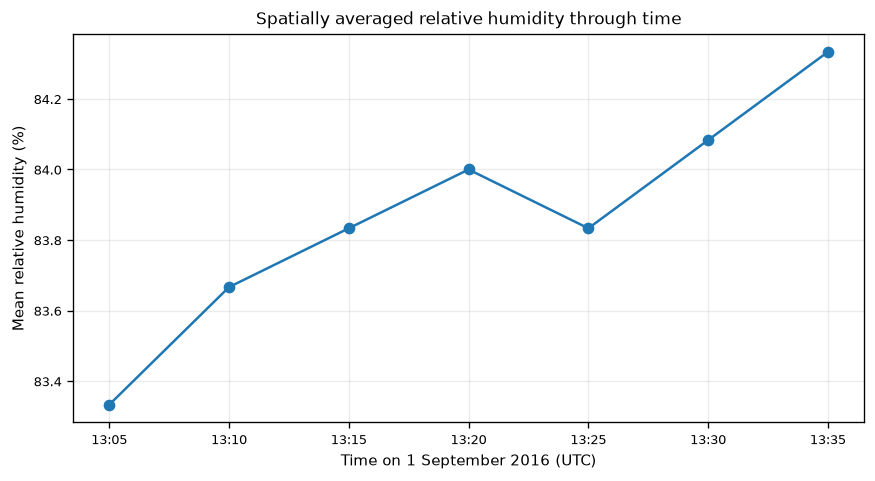

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["mean_relative_humidity_percent"],
    marker="o",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Mean relative humidity (%)")
ax.set_title("Spatially averaged relative humidity through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    config.NB020_DIR / "weather_humidity_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 16. Supplementary composite figures

The following two figures are generated directly from the weather observations
and derived profiles. They combine the principal atmospheric-structure and
temporal-variability diagnostics for use in the manuscript supplement. Only
PDF versions are written.


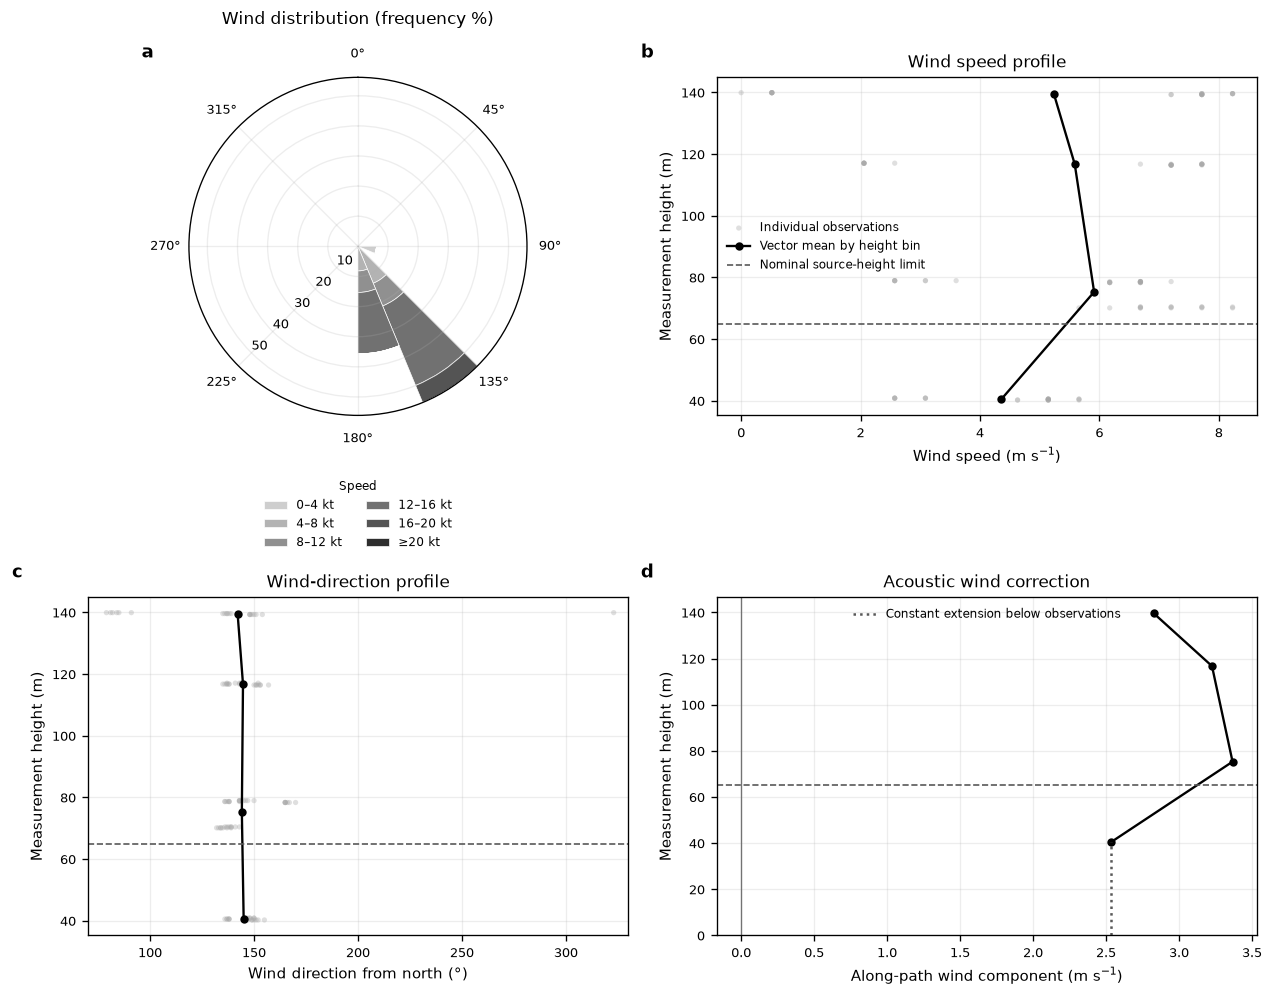

Saved /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/supplement_weather_wind_structure.pdf


In [17]:
# Supplementary Figure S1: wind structure and propagation correction
direction = weather["wind_direction_from_deg"].to_numpy(dtype=float)
speed_knots = weather["wind_speed_knots"].to_numpy(dtype=float)
valid = np.isfinite(direction) & np.isfinite(speed_knots)
direction = direction[valid]
speed_knots = speed_knots[valid]

direction_edges_deg = np.arange(0.0, 360.0 + 22.5, 22.5)
speed_edges_knots = np.array([0, 4, 8, 12, 16, 20, np.inf])
histogram = np.zeros(
    (len(direction_edges_deg) - 1, len(speed_edges_knots) - 1)
)
direction_wrapped = (
    direction + 0.5 * np.diff(direction_edges_deg)[0]
) % 360.0

for direction_index in range(len(direction_edges_deg) - 1):
    direction_mask = (
        (direction_wrapped >= direction_edges_deg[direction_index])
        & (direction_wrapped < direction_edges_deg[direction_index + 1])
    )
    for speed_index in range(len(speed_edges_knots) - 1):
        speed_mask = (
            (speed_knots >= speed_edges_knots[speed_index])
            & (speed_knots < speed_edges_knots[speed_index + 1])
        )
        histogram[direction_index, speed_index] = np.sum(
            direction_mask & speed_mask
        )

histogram = 100.0 * histogram / histogram.sum()
theta = np.deg2rad(
    direction_edges_deg[:-1] + 0.5 * np.diff(direction_edges_deg)
)
width = np.deg2rad(np.diff(direction_edges_deg))

fig = plt.figure(figsize=(10.5, 8.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
ax_rose = fig.add_subplot(grid[0, 0], projection="polar")
ax_speed = fig.add_subplot(grid[0, 1])
ax_direction = fig.add_subplot(grid[1, 0])
ax_along = fig.add_subplot(grid[1, 1])

# (a) Wind rose.
ax_rose.set_theta_zero_location("N")
ax_rose.set_theta_direction(-1)
bottom = np.zeros(len(theta))
rose_colours = plt.cm.Greys(
    np.linspace(0.30, 0.85, histogram.shape[1])
)
for speed_index, colour in enumerate(rose_colours):
    values = histogram[:, speed_index]
    upper_edge = speed_edges_knots[speed_index + 1]
    label = (
        f"{speed_edges_knots[speed_index]:g}–{upper_edge:g} kt"
        if np.isfinite(upper_edge)
        else f"≥{speed_edges_knots[speed_index]:g} kt"
    )
    ax_rose.bar(
        theta,
        values,
        width=width,
        bottom=bottom,
        align="center",
        color=colour,
        edgecolor="white",
        linewidth=0.4,
        label=label,
    )
    bottom += values
ax_rose.set_title("Wind distribution (frequency %)", pad=14)
ax_rose.set_rlabel_position(225)
ax_rose.legend(
    title="Speed",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False,
    fontsize=7,
    title_fontsize=7,
)

# (b) Wind speed versus height, expressed in SI units.
ax_speed.scatter(
    weather["wind_speed_mps"],
    weather["height_m"],
    s=10,
    color="0.65",
    alpha=0.35,
    edgecolors="none",
    label="Individual observations",
)
ax_speed.plot(
    height_profile["vector_mean_wind_speed_mps"],
    height_profile["mean_height_m"],
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
    label="Vector mean by height bin",
)
ax_speed.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    color="0.35",
    linestyle="--",
    linewidth=1.0,
    label="Nominal source-height limit",
)
ax_speed.set_xlabel("Wind speed (m s$^{-1}$)")
ax_speed.set_ylabel("Measurement height (m)")
ax_speed.set_title("Wind speed profile")
ax_speed.legend(frameon=False, fontsize=7)

# (c) Meteorological wind direction versus height.
ax_direction.scatter(
    weather["wind_direction_from_deg"],
    weather["height_m"],
    s=10,
    color="0.65",
    alpha=0.35,
    edgecolors="none",
)
ax_direction.plot(
    height_profile["vector_mean_wind_direction_from_deg"],
    height_profile["mean_height_m"],
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
)
ax_direction.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    color="0.35",
    linestyle="--",
    linewidth=1.0,
)
finite_direction = weather["wind_direction_from_deg"].dropna()
direction_min = max(0.0, 5.0 * np.floor(finite_direction.min() / 5.0) - 5.0)
direction_max = min(
    360.0,
    5.0 * np.ceil(finite_direction.max() / 5.0) + 5.0,
)
ax_direction.set_xlim(direction_min, direction_max)
ax_direction.set_xlabel("Wind direction from north (°)")
ax_direction.set_ylabel("Measurement height (m)")
ax_direction.set_title("Wind-direction profile")

# (d) Wind projected onto the source-to-receiver path.
ax_along.axvline(0.0, color="0.45", linewidth=0.8)
ax_along.plot(
    height_profile["wind_along_slc40_bchh_mps"],
    height_profile["mean_height_m"],
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
)
ax_along.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    color="0.35",
    linestyle="--",
    linewidth=1.0,
)
ax_along.set_xlabel("Along-path wind component (m s$^{-1}$)")
ax_along.set_ylabel("Measurement height (m)")
ax_along.set_title("Acoustic wind correction")
# Show the profile actually averaged, including its unmeasured lower portion.
valid_wind_profile = height_profile.dropna(subset=["mean_u_east_mps", "mean_v_north_mps"])
lowest_wind_height_m = float(valid_wind_profile["mean_height_m"].min())
lower_profile = path_wind["z_grid_m"] <= lowest_wind_height_m
ax_along.plot(
    along_ray_wind_component(path_wind["u_grid_mps"][lower_profile],
                             path_wind["v_grid_mps"][lower_profile], ray_azimuth_deg),
    path_wind["z_grid_m"][lower_profile],
    linestyle=":", color="0.35", label="Constant extension below observations",
)
ax_along.set_ylim(bottom=0)
ax_along.legend(frameon=False, fontsize=7)

for panel_label, axis in zip(
    ("a", "b", "c", "d"),
    (ax_rose, ax_speed, ax_direction, ax_along),
):
    axis.text(
        -0.14,
        1.10,
        panel_label,
        transform=axis.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
    )
    axis.grid(True, alpha=0.22)

wind_structure_path = (
    config.NB020_DIR / "supplement_weather_wind_structure.pdf"
)
fig.savefig(wind_structure_path, bbox_inches="tight")
plt.show()
print(f"Saved {wind_structure_path}")


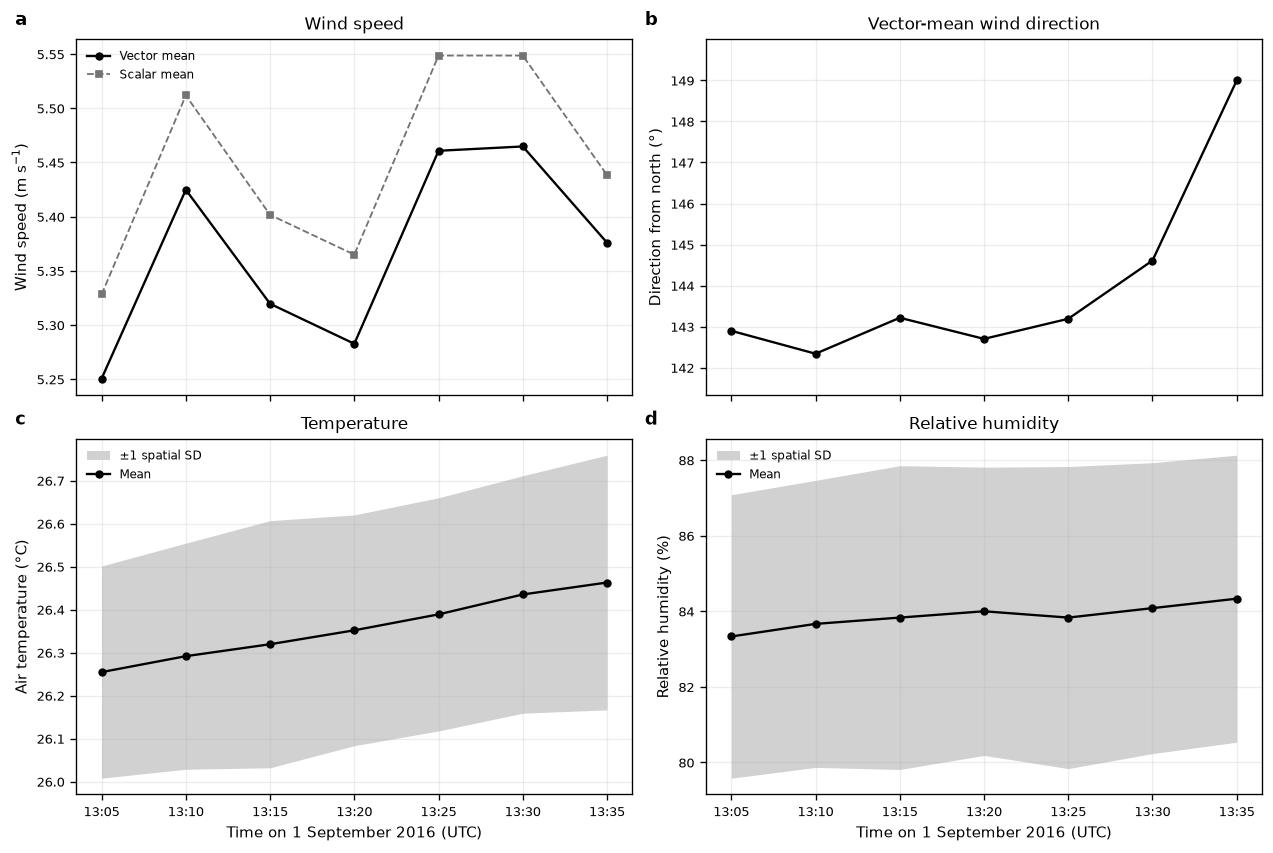

Saved /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/supplement_weather_temporal_variability.pdf


In [18]:
# Supplementary Figure S2: atmospheric conditions through time
times = pd.to_datetime(time_profile["datetime_utc"])

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.5, 7.0),
    sharex=True,
    constrained_layout=True,
)
ax_speed, ax_direction, ax_temperature, ax_humidity = axes.ravel()

# (a) Spatially averaged wind speeds.
ax_speed.plot(
    times,
    time_profile["vector_mean_wind_speed_mps"],
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
    label="Vector mean",
)
ax_speed.plot(
    times,
    time_profile["scalar_mean_wind_speed_mps"],
    "s--",
    color="0.45",
    linewidth=1.1,
    markersize=3.5,
    label="Scalar mean",
)
ax_speed.set_ylabel("Wind speed (m s$^{-1}$)")
ax_speed.set_title("Wind speed")
ax_speed.legend(frameon=False, fontsize=7)

# (b) Spatially averaged meteorological wind direction.
direction_time = time_profile[
    "vector_mean_wind_direction_from_deg"
].to_numpy(dtype=float)
ax_direction.plot(
    times,
    direction_time,
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
)
direction_pad = max(1.0, 0.15 * np.ptp(direction_time))
ax_direction.set_ylim(
    np.nanmin(direction_time) - direction_pad,
    np.nanmax(direction_time) + direction_pad,
)
ax_direction.set_ylabel("Direction from north (°)")
ax_direction.set_title("Vector-mean wind direction")

# (c) Temperature with spatial standard deviation among available observations.
temperature = time_profile["mean_temperature_c"].to_numpy(dtype=float)
temperature_std = time_profile["std_temperature_c"].to_numpy(dtype=float)
ax_temperature.fill_between(
    times,
    temperature - temperature_std,
    temperature + temperature_std,
    color="0.82",
    linewidth=0,
    label="±1 spatial SD",
)
ax_temperature.plot(
    times,
    temperature,
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
    label="Mean",
)
ax_temperature.set_ylabel("Air temperature (°C)")
ax_temperature.set_title("Temperature")
ax_temperature.legend(frameon=False, fontsize=7)

# (d) Relative humidity with spatial standard deviation.
humidity = time_profile[
    "mean_relative_humidity_percent"
].to_numpy(dtype=float)
humidity_std = time_profile[
    "std_relative_humidity_percent"
].to_numpy(dtype=float)
ax_humidity.fill_between(
    times,
    humidity - humidity_std,
    humidity + humidity_std,
    color="0.82",
    linewidth=0,
    label="±1 spatial SD",
)
ax_humidity.plot(
    times,
    humidity,
    "o-",
    color="black",
    linewidth=1.4,
    markersize=4,
    label="Mean",
)
ax_humidity.set_ylabel("Relative humidity (%)")
ax_humidity.set_title("Relative humidity")
ax_humidity.legend(frameon=False, fontsize=7)

for panel_label, axis in zip(("a", "b", "c", "d"), axes.ravel()):
    axis.text(
        -0.11,
        1.08,
        panel_label,
        transform=axis.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
    )
    axis.grid(True, alpha=0.22)
    axis.xaxis.set_major_formatter(DateFormatter("%H:%M"))

ax_temperature.set_xlabel("Time on 1 September 2016 (UTC)")
ax_humidity.set_xlabel("Time on 1 September 2016 (UTC)")

temporal_variability_path = (
    config.NB020_DIR / "supplement_weather_temporal_variability.pdf"
)
fig.savefig(temporal_variability_path, bbox_inches="tight")
plt.show()
print(f"Saved {temporal_variability_path}")


## 17. Concise values for the paper

In [19]:
print(
    f"Mean temperature: "
    f"{acoustic_summary['mean_temperature_f']:.1f} °F "
    f"({acoustic_summary['mean_temperature_c']:.1f} °C)"
)
print(
    f"Mean relative humidity: "
    f"{acoustic_summary['mean_relative_humidity_percent']:.1f}%"
)
print(
    f"Still-air sound speed: "
    f"{acoustic_summary['still_air_sound_speed_mps']:.1f} m/s"
)
print(
    f"0–{MAXIMUM_PATH_HEIGHT_M:.0f} m vector-mean wind: "
    f"{acoustic_summary['path_vector_mean_wind_speed_knots']:.2f} kt "
    f"from "
    f"{acoustic_summary['path_vector_mean_wind_direction_from_deg']:.1f}°"
)
print(
    f"Wind component along SLC-40 → BCHH: "
    f"{acoustic_summary['wind_along_ray_mps']:+.2f} m/s"
)
print(
    f"Wind-corrected effective sound speed: "
    f"{acoustic_summary['effective_sound_speed_mps']:.1f} m/s"
)
print(
    f"Still-air travel time: "
    f"{acoustic_summary['still_air_travel_time_s']:.3f} s"
)
print(
    f"Wind-corrected travel time: "
    f"{acoustic_summary['wind_corrected_travel_time_s']:.3f} s"
)
print(
    f"Wind travel-time correction: "
    f"{acoustic_summary['wind_travel_time_correction_s']:+.3f} s"
)

Mean temperature: 79.4 °F (26.4 °C)
Mean relative humidity: 83.9%
Still-air sound speed: 348.3 m/s
0–65 m vector-mean wind: 8.88 kt from 144.9°
Wind component along SLC-40 → BCHH: +2.65 m/s
Wind-corrected effective sound speed: 351.0 m/s
Still-air travel time: 4.076 s
Wind-corrected travel time: 4.046 s
Wind travel-time correction: -0.031 s
